In [1]:

import pandas as pd
import numpy as np
import matplotlib
import statsmodels
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
import itertools

warnings.filterwarnings('ignore')
import os


In [2]:
os.chdir(r"C:\Users\BIG SHARK TECHNOLOGY\Desktop\Electricity vs GDP")
os.getcwd()

'C:\\Users\\BIG SHARK TECHNOLOGY\\Desktop\\Electricity vs GDP'

In [3]:
elec=pd.read_csv("data/raw/electricity.csv")
gdp = pd.read_csv("data/raw/gdp.csv")
gdp

,Country Name,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,12187.536361,13233.990517,13892.605143,14700.959808,16055.287787,16548.717387,16620.954556,17750.009564,18828.087059,...,27458.220154,27441.550214,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129
1,Africa Eastern and Southern,822.402999,864.174086,732.910915,709.323534,700.772126,766.522931,746.787335,767.399412,697.079415,...,1498.875240,1334.470500,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356
2,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,565.569730,522.082216,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN
3,Africa Western and Central,593.024667,607.840414,567.153365,574.472939,580.008123,866.731606,1069.590240,1091.831529,1141.486651,...,1860.727686,1630.039439,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029
4,Angola,965.866840,881.919488,668.706017,449.727895,334.973590,404.294818,531.115367,521.702915,429.188127,...,3641.728939,2051.814621,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3520.628507,3759.449591,4009.320221,4384.187964,4415.999230,4310.889638,5270.432369,5290.950065,6221.206188,7023.065985
262,"Yemen, Rep.",910.422466,1016.302230,1198.130317,1396.615444,1735.044195,764.414656,375.214995,382.584929,342.739407,...,1362.173812,975.359417,811.165970,633.887202,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,3093.489204,3243.236160,3462.394002,3399.640096,3488.597115,3855.634087,3617.553360,3700.235548,3309.609331,...,6112.273825,5651.205852,6618.335083,6914.178032,6533.711210,5580.603831,6828.756246,6534.248678,6034.272090,6267.186814
264,Zambia,422.336299,423.071257,389.254666,390.916674,426.386598,433.312783,399.511305,465.871942,373.084763,...,1295.877887,1239.085279,1483.465773,1463.899979,1258.986198,951.644317,1127.160779,1447.123101,1330.727806,1187.109434


In [4]:
elec = elec.melt(
    id_vars=["Country Name"],   
    var_name="Year",        
    value_name="elec_access" 
)

gdp = gdp.melt(
    id_vars=["Country Name"],   
    var_name="Year",        
    value_name="gdp_pc" 
)


In [5]:
elec["Year"] = elec["Year"].astype(int)
gdp["Year"] = gdp["Year"].astype(int)

In [6]:
df = pd.merge(
    elec,
    gdp,
    on = ["Country Name", "Year"],
    how = "inner"
)

df.rename(columns={"Country Name": "country"}, inplace = True)
df

,country,Year,elec_access,gdp_pc
0,Aruba,1990,100.0,12187.536361
1,Africa Eastern and Southern,1990,NaN,822.402999
2,Afghanistan,1990,NaN,NaN
3,Africa Western and Central,1990,NaN,593.024667
4,Angola,1990,NaN,965.866840
...,...,...,...,...
9305,Kosovo,2024,NaN,7023.065985
9306,"Yemen, Rep.",2024,NaN,NaN
9307,South Africa,2024,NaN,6267.186814
9308,Zambia,2024,NaN,1187.109434


In [7]:
african_countries = ["Cameroon", "Ghana", "Nigeria", "Cote d'Ivoire"]

df = df[df["country"].isin(african_countries)].dropna(subset = ["elec_access", "gdp_pc"])
df = df.sort_values(["country", "Year"]).reset_index(drop=True)

df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   country      128 non-null    object 
 1   Year         128 non-null    int64  
 2   elec_access  128 non-null    float64
 3   gdp_pc       128 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 4.1+ KB


,country,Year,elec_access,gdp_pc
0,Cameroon,1991,29.000000,1014.828973
1,Cameroon,1992,32.697525,1005.448976
2,Cameroon,1993,33.849194,1309.936300
3,Cameroon,1994,34.999504,700.709502
4,Cameroon,1995,36.147774,832.006674
...,...,...,...,...
123,Nigeria,2019,55.400000,3189.812865
124,Nigeria,2020,55.400000,2797.184581
125,Nigeria,2021,59.500000,2787.487792
126,Nigeria,2022,60.500000,2899.160475


In [8]:
df.to_csv("data/processed/processed_data.csv")

In [9]:
df[["elec_access", "gdp_pc"]].describe()

,elec_access,gdp_pc
count,128.00000,128.000000
mean,53.37533,1413.537097
std,13.39323,704.754371
min,27.30000,253.746936
25%,43.97500,819.910397
50%,52.45000,1428.360135
75%,60.95000,1885.375182
max,89.50000,3189.812865


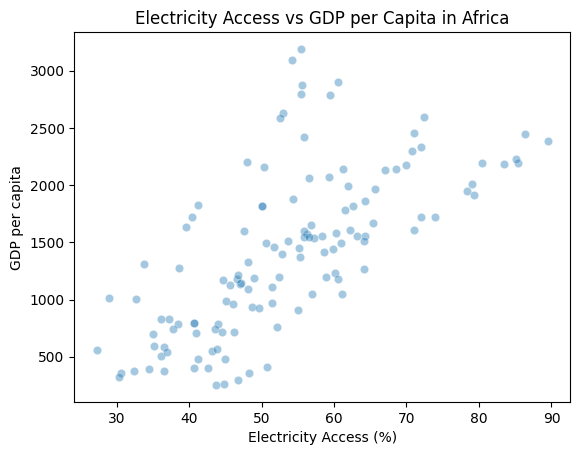

In [10]:
sns.scatterplot(data = df, x= "elec_access", y="gdp_pc", alpha = 0.4)
plt.xlabel("Electricity Access (%)")
plt.ylabel("GDP per capita")
plt.title("Electricity Access vs GDP per Capita in Africa")
plt.show()


In [11]:
corr = df[["elec_access", "gdp_pc"]].corr()
corr

,elec_access,gdp_pc
elec_access,1.000000,0.676105
gdp_pc,0.676105,1.000000


In [12]:
model_ols = smf.ols(
    "gdp_pc ~ elec_access",
    data = df
).fit()
model_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 gdp_pc   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.453
Method:                 Least Squares   F-statistic:                     106.1
Date:                Mon, 02 Feb 2026   Prob (F-statistic):           2.01e-18
Time:                        15:27:44   Log-Likelihood:                -981.43
No. Observations:                 128   AIC:                             1967.
Df Residuals:                     126   BIC:                             1973.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    -485.3839    190.029     -2.554      0.012    -861.445    -109.323
elec_access    35.5768      3.454     10.300      0.000      28.741      42.412
==============================================================================
Omnibus:                       26.253   Durbin-Watson:                   0.292
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               35.419
Skew:                           1.114   Prob(JB):                     2.04e-08
Kurtosis:                       4.295   Cond. No.                         227.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [13]:
model_fe = smf.ols(
    "gdp_pc ~ elec_access + C(country)",
    data=df
).fit()

print(model_fe.summary())


                            OLS Regression Results                            
Dep. Variable:                 gdp_pc   R-squared:                       0.691
Model:                            OLS   Adj. R-squared:                  0.681
Method:                 Least Squares   F-statistic:                     68.84
Date:                Mon, 02 Feb 2026   Prob (F-statistic):           1.78e-30
Time:                        15:27:44   Log-Likelihood:                -945.32
No. Observations:                 128   AIC:                             1901.
Df Residuals:                     123   BIC:                             1915.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [14]:
model_fe_time = smf.ols(
    "gdp_pc ~ elec_access + C(country) + C(Year)",
    data=df
).fit()

(model_fe_time.summary())


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 gdp_pc   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                     12.82
Date:                Mon, 02 Feb 2026   Prob (F-statistic):           9.50e-23
Time:                        15:27:44   Log-Likelihood:                -903.04
No. Observations:                 128   AIC:                             1882.
Df Residuals:                      90   BIC:                             1990.
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                    -314.0374    386.631     -0.812      0.419   -1082.147     454.072
C(country)[T.Cote d'Ivoire]   155.0800     92.205      1.682      0.096     -28.102     338.262
C(country)[T.Ghana]          -201.2912     98.404     -2.046      0.044    -396.787      -5.795
C(country)[T.Nigeria]         512.8476     82.630      6.207      0.000     348.688     677.007
C(Year)[T.1991]               442.8359    412.363      1.074      0.286    -376.394    1262.066
C(Year)[T.1992]               364.0561    413.493      0.880      0.381    -457.420    1185.532
C(Year)[T.1993]               503.8649    389.449      1.294      0.199    -269.842    1277.572
C(Year)[T.1994]               326.9540    377.800      0.865      0.389    -423.611    1077.519
C(Year)[T.1995]               507.1225    379.116      1.338      0.184    -246.057    1260.302
C(Year)[T.1996]               691.3176    379.973      1.819      0.072     -63.566    1446.201
C(Year)[T.1997]               671.3733    380.989      1.762      0.081     -85.527    1428.274
C(Year)[T.1998]               686.4653    383.480      1.790      0.077     -75.385    1448.315
C(Year)[T.1999]               319.8639    384.434      0.832      0.408    -443.881    1083.609
C(Year)[T.2000]               230.6833    385.055      0.599      0.551    -534.296     995.663
C(Year)[T.2001]               210.4631    387.716      0.543      0.589    -559.802     980.728
C(Year)[T.2002]               277.4839    388.513      0.714      0.477    -494.365    1049.333
C(Year)[T.2003]               357.2911    392.615      0.910      0.365    -422.707    1137.289
C(Year)[T.2004]               479.7409    392.317      1.223      0.225    -299.666    1259.147
C(Year)[T.2005]               569.0767    391.399      1.454      0.149    -208.506    1346.659
C(Year)[T.2006]               735.4958    399.544      1.841      0.069     -58.269    1529.260
C(Year)[T.2007]               897.8293    398.838      2.251      0.027     105.468    1690.191
C(Year)[T.2008]              1074.6594    404.778      2.655      0.009     270.498    1878.821
C(Year)[T.2009]               944.1880    403.889      2.338      0.022     141.792    1746.584
C(Year)[T.2010]              1070.4451    405.736      2.638      0.010     264.380    1876.510
C(Year)[T.2011]              1205.0093    409.295      2.944      0.004     391.874    2018.145
C(Year)[T.2012]              1268.6239    404.110      3.139      0.002     465.789    2071.459
C(Year)[T.2013]              1530.5119    418.551      3.657      0.000     698.988    2362.036
C(Year)[T.2014]              1544.7046    423.412      3.648      0.000     703.522    2385.887
C(Year)[T.2015]              1270.8618    420.987      3.019      0.003     434.498    2107.226
C(Year)[T.2

In [15]:
model_fe_time_clustered = smf.ols(
    "gdp_pc ~ elec_access + C(country) + C(Year)",
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["country"]}
)
model_fe_time_clustered.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 gdp_pc   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                 1.248e+12
Date:                Mon, 02 Feb 2026   Prob (F-statistic):           1.22e-18
Time:                        15:27:44   Log-Likelihood:                -903.04
No. Observations:                 128   AIC:                             1882.
Df Residuals:                      90   BIC:                             1990.
Df Model:                          37                                         
Covariance Type:              cluster                                         
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                    -314.0374    507.926     -0.618      0.536   -1309.554     681.479
C(country)[T.Cote d'Ivoire]   155.0800     83.568      1.856      0.063      -8.711     318.871
C(country)[T.Ghana]          -201.2912    130.270     -1.545      0.122    -456.616      54.033
C(country)[T.Nigeria]         512.8476     21.087     24.320      0.000     471.517     554.178
C(Year)[T.1991]               442.8359    450.584      0.983      0.326    -440.293    1325.965
C(Year)[T.1992]               364.0561    452.570      0.804      0.421    -522.964    1251.076
C(Year)[T.1993]               503.8649    390.492      1.290      0.197    -261.485    1269.215
C(Year)[T.1994]               326.9540     74.819      4.370      0.000     180.311     473.597
C(Year)[T.1995]               507.1225    162.779      3.115      0.002     188.081     826.164
C(Year)[T.1996]               691.3176    255.592      2.705      0.007     190.367    1192.269
C(Year)[T.1997]               671.3733    309.252      2.171      0.030      65.250    1277.496
C(Year)[T.1998]               686.4653    390.795      1.757      0.079     -79.478    1452.409
C(Year)[T.1999]               319.8639    162.984      1.963      0.050       0.421     639.307
C(Year)[T.2000]               230.6833    179.651      1.284      0.199    -121.427     582.794
C(Year)[T.2001]               210.4631    198.910      1.058      0.290    -179.393     600.319
C(Year)[T.2002]               277.4839    232.226      1.195      0.232    -177.671     732.639
C(Year)[T.2003]               357.2911    278.372      1.284      0.199    -188.309     902.891
C(Year)[T.2004]               479.7409    324.705      1.477      0.140    -156.669    1116.151
C(Year)[T.2005]               569.0767    302.913      1.879      0.060     -24.621    1162.775
C(Year)[T.2006]               735.4958    413.323      1.779      0.075     -74.603    1545.595
C(Year)[T.2007]               897.8293    419.780      2.139      0.032      75.075    1720.583
C(Year)[T.2008]              1074.6594    532.614      2.018      0.044      30.755    2118.564
C(Year)[T.2009]               944.1880    473.141      1.996      0.046      16.849    1871.527
C(Year)[T.2010]              1070.4451    558.071      1.918      0.055     -23.354    2164.245
C(Year)[T.2011]              1205.0093    561.865      2.145      0.032     103.775    2306.244
C(Year)[T.2012]              1268.6239    581.148      2.183      0.029     129.595    2407.653
C(Year)[T.2013]              1530.5119    643.260      2.379      0.017     269.746    2791.278
C(Year)[T.2014]              1544.7046    787.502      1.962      0.050       1.229    3088.181
C(Year)[T.2015]              1270.8618    691.123      1.839      0.066     -83.714    2625.437
C(Year)[T.2

In [16]:
df["log_gdp_pc"] = np.log(df["gdp_pc"])

model_log = smf.ols(
    "log_gdp_pc ~ elec_access + C(country) + C(Year)",
    data = df
).fit(
    cov_type = "cluster",
    cov_kwds = {"groups": df["country"]}
)

model_log.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_gdp_pc   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                 3.183e+11
Date:                Mon, 02 Feb 2026   Prob (F-statistic):           9.45e-18
Time:                        15:27:44   Log-Likelihood:                 7.6210
No. Observations:                 128   AIC:                             60.76
Df Residuals:                      90   BIC:                             169.1
Df Model:                          37                                         
Covariance Type:              cluster                                         
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       5.3121      0.428     12.424      0.000       4.474       6.150
C(country)[T.Cote d'Ivoire]    -0.0197      0.073     -0.269      0.788      -0.163       0.124
C(country)[T.Ghana]            -0.5586      0.110     -5.058      0.000      -0.775      -0.342
C(country)[T.Nigeria]           0.2516      0.018     14.174      0.000       0.217       0.286
C(Year)[T.1991]                 0.3278      0.433      0.756      0.449      -0.522       1.177
C(Year)[T.1992]                 0.1797      0.455      0.395      0.693      -0.712       1.071
C(Year)[T.1993]                 0.3033      0.366      0.829      0.407      -0.413       1.020
C(Year)[T.1994]                 0.1256      0.046      2.735      0.006       0.036       0.216
C(Year)[T.1995]                 0.3216      0.184      1.747      0.081      -0.039       0.682
C(Year)[T.1996]                 0.4732      0.244      1.941      0.052      -0.005       0.951
C(Year)[T.1997]                 0.4200      0.293      1.434      0.152      -0.154       0.994
C(Year)[T.1998]                 0.3951      0.365      1.082      0.279      -0.321       1.111
C(Year)[T.1999]                 0.0218      0.176      0.124      0.901      -0.323       0.367
C(Year)[T.2000]                -0.1441      0.266     -0.543      0.587      -0.665       0.376
C(Year)[T.2001]                -0.1824      0.271     -0.672      0.501      -0.714       0.349
C(Year)[T.2002]                -0.0741      0.294     -0.252      0.801      -0.651       0.503
C(Year)[T.2003]                 0.0090      0.297      0.030      0.976      -0.572       0.590
C(Year)[T.2004]                 0.1565      0.340      0.460      0.645      -0.510       0.823
C(Year)[T.2005]                 0.2719      0.261      1.043      0.297      -0.239       0.783
C(Year)[T.2006]                 0.3954      0.343      1.154      0.249      -0.276       1.067
C(Year)[T.2007]                 0.5267      0.315      1.673      0.094      -0.090       1.144
C(Year)[T.2008]                 0.5877      0.396      1.483      0.138      -0.189       1.365
C(Year)[T.2009]                 0.5143      0.374      1.374      0.169      -0.219       1.248
C(Year)[T.2010]                 0.5771      0.435      1.326      0.185      -0.276       1.430
C(Year)[T.2011]                 0.6288      0.382      1.647      0.100      -0.120       1.377
C(Year)[T.2012]                 0.6997      0.370      1.892      0.058      -0.025       1.424
C(Year)[T.2013]                 0.7137      0.450      1.584      0.113      -0.169       1.597
C(Year)[T.2014]                 0.6804      0.567      1.200      0.230      -0.431       1.792
C(Year)[T.2015]                 0.5678      0.534      1.064      0.287      -0.478       1.614
C(Year)[T.2

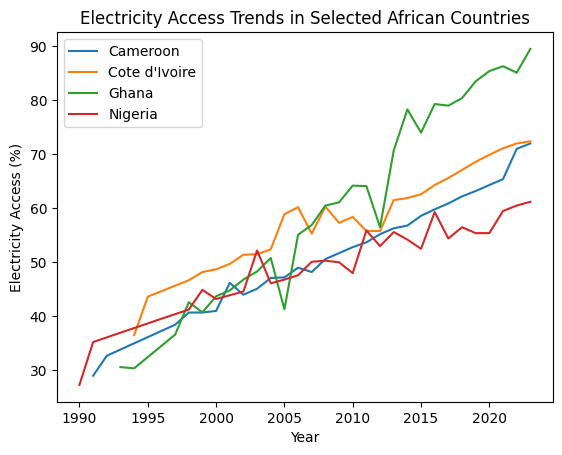

In [17]:
for c in df["country"].unique():
    subset = df[df["country"] == c]
    plt.plot(subset["Year"], subset["elec_access"], label=c)

plt.xlabel("Year")
plt.ylabel("Electricity Access (%)")
plt.title("Electricity Access Trends in Selected African Countries")
plt.legend()
plt.show()

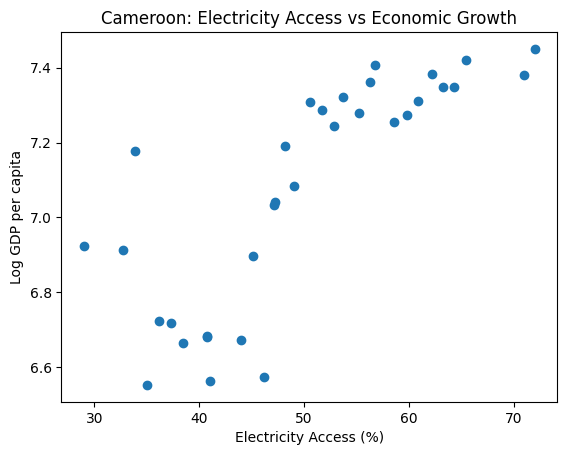

In [18]:
cam = df[df['country'] == 'Cameroon']
plt.scatter(cam['elec_access'], cam['log_gdp_pc'])
plt.xlabel("Electricity Access (%)")
plt.ylabel("Log GDP per capita")
plt.title("Cameroon: Electricity Access vs Economic Growth")
plt.show()


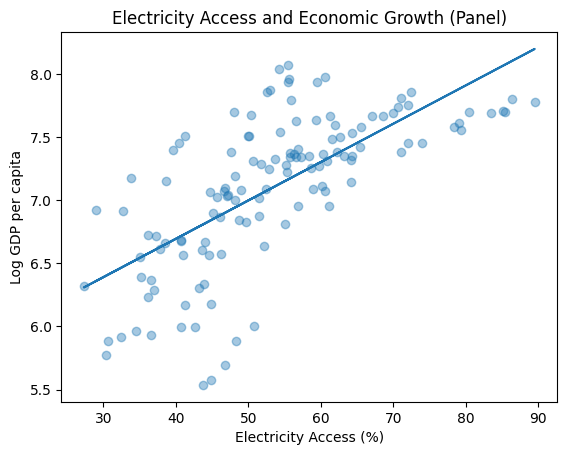

In [19]:
plt.scatter(df['elec_access'], df['log_gdp_pc'], alpha=0.4)
z = np.polyfit(df['elec_access'], df['log_gdp_pc'], 1)
p = np.poly1d(z)
plt.plot(df['elec_access'], p(df['elec_access']))
plt.xlabel("Electricity Access (%)")
plt.ylabel("Log GDP per capita")
plt.title("Electricity Access and Economic Growth (Panel)")
plt.show()


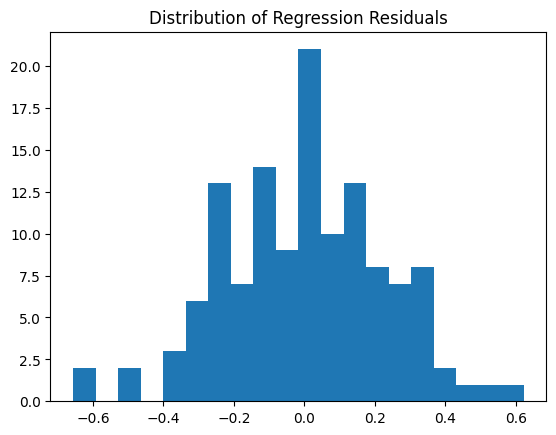

In [20]:
resid = model_log.resid
plt.hist(resid, bins=20)
plt.title("Distribution of Regression Residuals")
plt.show()
